In [ ]:
# 03_train_baseline_world_model.ipynb
import os, json, math, time, pickle, random, glob
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm.auto import tqdm

SEED_BASE = 1337

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE: cuda
GPU: NVIDIA L4


In [ ]:
# Cell 1: Mount Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# Cell 2: Paths + load sequence indices + shard map
DATASET_PATH = "/content/drive/MyDrive/AIAGENT_FINAL/obtain_diamond_v3_fixdone"
SEQ_DIR = "/content/drive/MyDrive/AIAGENT_FINAL/outputs_sequences"

OUT_ROOT = "/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model"
os.makedirs(OUT_ROOT, exist_ok=True)

train_pkl = os.path.join(SEQ_DIR, "train_sequences.pkl")
val_pkl   = os.path.join(SEQ_DIR, "val_sequences.pkl")
test_pkl  = os.path.join(SEQ_DIR, "test_sequences.pkl")
meta_json = os.path.join(SEQ_DIR, "sequences_meta.json")

with open(train_pkl, "rb") as f: train_seqs = pickle.load(f)
with open(val_pkl, "rb") as f:   val_seqs   = pickle.load(f)
with open(test_pkl, "rb") as f:  test_seqs  = pickle.load(f)
with open(meta_json, "r") as f:  seq_meta   = json.load(f)

print("Loaded seq indices:",
      "train", len(train_seqs),
      "val", len(val_seqs),
      "test", len(test_seqs))

# map basename -> full path
shards = sorted(glob.glob(os.path.join(DATASET_PATH, "shard_*.npz")))
path_map = {os.path.basename(p): p for p in shards}
assert len(path_map) == 30

# integrity check
def check(seqs, name):
    names = {s["shard"] for s in seqs}
    missing = sorted(list(names - set(path_map.keys())))
    assert len(missing) == 0, f"{name} references missing shards: {missing[:5]}"
check(train_seqs, "train")
check(val_seqs, "val")
check(test_seqs, "test")
print("Shard references OK.")

Loaded seq indices: train 200000 val 150952 test 149650
Shard references OK.


In [ ]:
# Cell 3: compute train-state normalization stats for fair comparison to RSSM
train_shard_names = set(seq_meta["splits"]["train_shards"])

sum_x = np.zeros((28,), dtype=np.float64)
sum_x2 = np.zeros((28,), dtype=np.float64)
count = 0

for shard_name in train_shard_names:
    with np.load(path_map[shard_name]) as d:
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        state = np.concatenate([obs, mainhand], axis=1)
    sum_x += state.sum(axis=0)
    sum_x2 += (state ** 2).sum(axis=0)
    count += state.shape[0]

state_mean = (sum_x / count).astype(np.float32)
state_var = (sum_x2 / count) - (sum_x / count) ** 2
state_std = np.sqrt(np.maximum(state_var, 1e-8)).astype(np.float32)

print("state_mean shape:", state_mean.shape)
print("state_std shape:", state_std.shape)
print("min std:", float(state_std.min()), "max std:", float(state_std.max()))

state_mean shape: (28,)
state_std shape: (28,)
min std: 9.999999747378752e-05 max std: 173.99310302734375


In [ ]:
# Cell 4: Hyperparameters
# Instead of "toy epochs", we define a training budget in optimizer steps.
CFG = {
    "model": "MLPWorldModel",
    "state_dim": 28,
    "action_dim": 15,
    "hidden": 512,
    "depth": 3,              # number of hidden layers
    "dropout": 0.1,

    "seq_len": int(seq_meta["seq_len"]),  # 50
    "batch_size": 1024,       # large batch is fine for this MLP on A100
    "num_workers": 0,

    "lr": 3e-4,
    "weight_decay": 1e-6,
    "grad_clip": 1.0,

    # Training budget: number of optimizer steps (paper-like)
    "max_steps": 30000,        # increase to 50000 if you want; 30000 is already non-toy
    "log_every": 50,
    "eval_every": 500,         # evaluate on val every N steps
    "early_stop_patience": 8,  # number of evals without improvement
    "min_delta": 1e-5,

    # Use subsampled val for speed if needed (None = full)
    "val_eval_cap": 30000,     # cap for faster eval; keep full test later
    "test_eval_cap": 50000,
}

print(json.dumps(CFG, indent=2))

{
  "model": "MLPWorldModel",
  "state_dim": 28,
  "action_dim": 15,
  "hidden": 512,
  "depth": 3,
  "dropout": 0.1,
  "seq_len": 50,
  "batch_size": 1024,
  "num_workers": 0,
  "lr": 0.0003,
  "weight_decay": 1e-06,
  "grad_clip": 1.0,
  "max_steps": 30000,
  "log_every": 50,
  "eval_every": 500,
  "early_stop_patience": 8,
  "min_delta": 1e-05,
  "val_eval_cap": 30000,
  "test_eval_cap": 50000
}


In [ ]:
# Cell 5: Dataset that returns random (s_t, a_t, s_{t+1}) transitions from sequences
class TransitionDataset(Dataset):
    """
    Each item picks a sequence (shard, t0) and then samples a random step inside it:
        s_t, a_t, s_{t+1}
    This yields i.i.d. transitions while preserving episode boundary correctness.
    """
    def __init__(self, seq_list, path_map, seq_len=50):
        self.seq_list = seq_list
        self.path_map = path_map
        self.seq_len = seq_len
        self.cache = {}  # shard -> loaded arrays (optional; can grow; acceptable with 30 shards)

    def __len__(self):
        return len(self.seq_list)

    def _load_shard(self, shard_name):
        if shard_name in self.cache:
            return self.cache[shard_name]
        p = self.path_map[shard_name]
        d = np.load(p)
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        action = d["action"].astype(np.float32)
        done = d["done"].astype(bool)
        state = np.concatenate([obs, mainhand], axis=1)  # (N,28)
        # cache
        self.cache[shard_name] = (state, action, done)
        return self.cache[shard_name]

    def __getitem__(self, idx):
        rec = self.seq_list[idx]
        shard = rec["shard"]
        t0 = int(rec["t0"])
        L  = int(rec["length"])  # should be seq_len

        state, action, done = self._load_shard(shard)

        # sample step uniformly from [0, L-1]
        k = np.random.randint(0, L)
        t = t0 + k

        # safety: done[t] should be False by construction
        # (sequence builder ensured no done inside window)
        s = state[t]
        a = action[t]
        s2 = state[t+1]

        return torch.from_numpy(s), torch.from_numpy(a), torch.from_numpy(s2)

In [ ]:
# Cell 6: Model definition (deterministic MLP)
class MLPWorldModel(nn.Module):
    def __init__(self, state_dim=28, action_dim=15, hidden=512, depth=3, dropout=0.1):
        super().__init__()
        layers = []
        in_dim = state_dim + action_dim
        for i in range(depth):
            layers.append(nn.Linear(in_dim if i == 0 else hidden, hidden))
            layers.append(nn.ReLU())
            if dropout and dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(hidden, state_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, s, a):
        x = torch.cat([s, a], dim=-1)
        return self.net(x)

In [ ]:
# Cell 7: Evaluation helpers (MSE)
import numpy as np
import torch

# global eval cache (cleared on runtime restart)
_EVAL_CACHE = {}

def _get_shard_cached(shard_name: str):
    """
    Returns (state, action) for a shard, cached in RAM.
    state: (N,28) float32
    action: (N,15) float32
    """
    if shard_name in _EVAL_CACHE:
        return _EVAL_CACHE[shard_name]

    p = path_map[shard_name]
    with np.load(p) as d:
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        action = d["action"].astype(np.float32)

    state = np.concatenate([obs, mainhand], axis=1)  # (N,28)
    _EVAL_CACHE[shard_name] = (state, action)
    return state, action

# New Cell 6.5 — normalized cached loader for fair comparison to RSSM
_EVAL_CACHE_NORM = {}

def _get_shard_cached_norm(shard_name: str):
    if shard_name in _EVAL_CACHE_NORM:
        return _EVAL_CACHE_NORM[shard_name]

    p = path_map[shard_name]
    with np.load(p) as d:
        obs = d["obs"].astype(np.float32)
        mainhand = d["mainhand"].astype(np.float32)
        action = d["action"].astype(np.float32)

    state_raw = np.concatenate([obs, mainhand], axis=1)
    state_norm = (state_raw - state_mean) / (state_std + 1e-8)

    _EVAL_CACHE_NORM[shard_name] = (state_norm, action)
    return state_norm, action


@torch.no_grad()
def eval_mse_deterministic(model, seqs, cap=None, batch_size=4096, step_offset=0, **kwargs):
    model.eval()
    if cap is not None and len(seqs) > cap:
        seqs = seqs[:cap]  # deterministic prefix

    total = 0.0
    n = 0

    for i in range(0, len(seqs), batch_size):
        batch = seqs[i:i+batch_size]
        S, A, S2 = [], [], []

        for rec in batch:
            shard = rec["shard"]
            t0 = int(rec["t0"])
            t = t0 + step_offset

            state, action = _get_shard_cached(shard)
            S.append(state[t])
            A.append(action[t])
            S2.append(state[t+1])

        s  = torch.from_numpy(np.stack(S)).to(DEVICE, non_blocking=True)
        a  = torch.from_numpy(np.stack(A)).to(DEVICE, non_blocking=True)
        s2 = torch.from_numpy(np.stack(S2)).to(DEVICE, non_blocking=True)

        pred = model(s, a)
        total += ((pred - s2) ** 2).mean(dim=1).sum().item()
        n += s.size(0)

    return total / max(n, 1)

@torch.no_grad()
def eval_mse_deterministic_normalized(model, seqs, cap=None, batch_size=4096, step_offset=0, **kwargs):
    model.eval()
    if cap is not None and len(seqs) > cap:
        seqs = seqs[:cap]

    total = 0.0
    n = 0

    mean_t = torch.from_numpy(state_mean).to(DEVICE)
    std_t = torch.from_numpy(state_std).to(DEVICE)

    for i in range(0, len(seqs), batch_size):
        batch = seqs[i:i+batch_size]
        S_raw, A, S2_raw = [], [], []

        for rec in batch:
            shard = rec["shard"]
            t0 = int(rec["t0"])
            t = t0 + step_offset

            state_raw, action = _get_shard_cached(shard)   # RAW input
            S_raw.append(state_raw[t])
            A.append(action[t])
            S2_raw.append(state_raw[t+1])

        s_raw = torch.from_numpy(np.stack(S_raw)).to(DEVICE, non_blocking=True)
        a = torch.from_numpy(np.stack(A)).to(DEVICE, non_blocking=True)
        s2_raw = torch.from_numpy(np.stack(S2_raw)).to(DEVICE, non_blocking=True)

        pred_raw = model(s_raw, a)

        pred_norm = (pred_raw - mean_t) / (std_t + 1e-8)
        s2_norm = (s2_raw - mean_t) / (std_t + 1e-8)

        total += ((pred_norm - s2_norm) ** 2).mean(dim=1).sum().item()
        n += s_raw.size(0)

    return total / max(n, 1)

In [ ]:
# Cell 8: Training loop (budgeted steps + early stopping + scheduler)
def train_one_run(run_dir, seed):
    set_seed(seed)

    # datasets / loaders
    train_ds = TransitionDataset(train_seqs, path_map, seq_len=CFG["seq_len"])
    train_dl = DataLoader(
        train_ds,
        batch_size=CFG["batch_size"],
        shuffle=True,
        num_workers=CFG["num_workers"],
        pin_memory=True,
        drop_last=True,
    )

    model = MLPWorldModel(
        state_dim=CFG["state_dim"],
        action_dim=CFG["action_dim"],
        hidden=CFG["hidden"],
        depth=CFG["depth"],
        dropout=CFG["dropout"],
    ).to(DEVICE)

    opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="min",
        factor=0.5,
        patience=2
    )

    loss_fn = nn.MSELoss()

    # logging
    os.makedirs(run_dir, exist_ok=True)
    config_path = os.path.join(run_dir, "config.json")
    log_path    = os.path.join(run_dir, "train_log.json")
    ckpt_path   = os.path.join(run_dir, "checkpoint.pt")

    with open(config_path, "w") as f:
        json.dump({"seed": seed, **CFG, "seq_meta": seq_meta}, f, indent=2)

    log = {
        "seed": seed,
        "train_steps": [],
        "train_loss": [],
        "val_steps": [],
        "val_mse": [],
        "lr": [],
        "best_val_mse": None,
        "best_step": None,
        "stopped_early": False,
        "total_time_sec": None,
    }

    best_val = float("inf")
    best_step = -1
    bad_evals = 0

    t0 = time.time()

    # infinite iterator over train_dl
    dl_iter = iter(train_dl)

    pbar = tqdm(range(1, CFG["max_steps"] + 1), desc=f"train(seed={seed})", leave=True)
    running = 0.0
    running_n = 0

    for step in pbar:
        try:
            s, a, s2 = next(dl_iter)
        except StopIteration:
            dl_iter = iter(train_dl)
            s, a, s2 = next(dl_iter)

        s = s.to(DEVICE, non_blocking=True)
        a = a.to(DEVICE, non_blocking=True)
        s2 = s2.to(DEVICE, non_blocking=True)

        pred = model(s, a)
        loss = loss_fn(pred, s2)

        opt.zero_grad(set_to_none=True)
        loss.backward()
        if CFG["grad_clip"] is not None:
            nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        opt.step()

        running += loss.item()
        running_n += 1

        if step % CFG["log_every"] == 0:
            avg_loss = running / max(running_n, 1)
            running = 0.0
            running_n = 0
            lr = opt.param_groups[0]["lr"]

            log["train_steps"].append(step)
            log["train_loss"].append(float(avg_loss))
            log["lr"].append(float(lr))

            pbar.set_postfix({"loss": f"{avg_loss:.4f}", "lr": f"{lr:.2e}"})

        # periodic validation
        if step % CFG["eval_every"] == 0 or step == CFG["max_steps"]:
            val_mse = eval_mse_deterministic(
                model,
                val_seqs,
                cap=CFG["val_eval_cap"],
                batch_size=4096,
                num_workers=0,
                seed=seed + 999,
            )
            log["val_steps"].append(step)
            log["val_mse"].append(float(val_mse))

            # scheduler step on val
            sched.step(val_mse)

            improved = (best_val - val_mse) > CFG["min_delta"]
            if improved:
                best_val = val_mse
                best_step = step
                bad_evals = 0

                # save best checkpoint
                torch.save(
                    {
                        "state_dict": model.state_dict(),
                        "cfg": CFG,
                        "seq_meta": seq_meta,
                        "seed": seed,
                        "best_val_mse": float(best_val),
                        "best_step": int(best_step),
                    },
                    ckpt_path,
                )
            else:
                bad_evals += 1

            log["best_val_mse"] = float(best_val)
            log["best_step"] = int(best_step)

            # write log every eval
            with open(log_path, "w") as f:
                json.dump(log, f, indent=2)

            if bad_evals >= CFG["early_stop_patience"]:
                log["stopped_early"] = True
                break

    log["total_time_sec"] = float(time.time() - t0)
    with open(log_path, "w") as f:
        json.dump(log, f, indent=2)

    print("Run finished. best_val_mse=", best_val, "best_step=", best_step, "saved:", ckpt_path)
    return ckpt_path, log

In [ ]:
# Cell 9: Run 3 seeds
seeds = [SEED_BASE, SEED_BASE + 1, SEED_BASE + 2]
run_dirs = []
ckpts = []
logs = []

for s in seeds:
    run_dir = os.path.join(OUT_ROOT, f"seed_{s}")
    run_dirs.append(run_dir)
    ckpt, lg = train_one_run(run_dir, s)
    ckpts.append(ckpt)
    logs.append(lg)

print("Done. Checkpoints:", ckpts)

train(seed=1337):   0%|          | 0/30000 [00:00<?, ?it/s]

Run finished. best_val_mse= 2.6766466227213543 best_step= 23500 saved: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1337/checkpoint.pt


train(seed=1338):   0%|          | 0/30000 [00:00<?, ?it/s]

Run finished. best_val_mse= 2.6577637532552085 best_step= 13500 saved: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1338/checkpoint.pt


train(seed=1339):   0%|          | 0/30000 [00:00<?, ?it/s]

Run finished. best_val_mse= 2.6802391438802085 best_step= 16500 saved: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1339/checkpoint.pt
Done. Checkpoints: ['/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1337/checkpoint.pt', '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1338/checkpoint.pt', '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1339/checkpoint.pt']


In [ ]:
# Cell 10: Final TEST evaluation (load best checkpoints and report test MSE)
@torch.no_grad()
def load_ckpt(path):
    ckpt = torch.load(path, map_location=DEVICE)
    m = MLPWorldModel(
        state_dim=ckpt["cfg"]["state_dim"],
        action_dim=ckpt["cfg"]["action_dim"],
        hidden=ckpt["cfg"]["hidden"],
        depth=ckpt["cfg"]["depth"],
        dropout=ckpt["cfg"]["dropout"],
    ).to(DEVICE)
    m.load_state_dict(ckpt["state_dict"])
    m.eval()
    return m, ckpt

test_results = []
for ckpt_path in ckpts:
    model, ckpt = load_ckpt(ckpt_path)
    test_mse = eval_mse_deterministic(
        model,
        test_seqs,
        cap=CFG["test_eval_cap"],
        batch_size=4096,
        num_workers=0,
        seed=ckpt["seed"] + 2024,
    )
    test_results.append({
        "seed": int(ckpt["seed"]),
        "best_val_mse": float(ckpt["best_val_mse"]),
        "best_step": int(ckpt["best_step"]),
        "test_mse": float(test_mse),
        "ckpt": ckpt_path,
    })

print("TEST results:")
for r in test_results:
    print(r)

TEST results:
{'seed': 1337, 'best_val_mse': 2.6766466227213543, 'best_step': 23500, 'test_mse': 2.062360634765625, 'ckpt': '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1337/checkpoint.pt'}
{'seed': 1338, 'best_val_mse': 2.6577637532552085, 'best_step': 13500, 'test_mse': 2.0573361279296876, 'ckpt': '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1338/checkpoint.pt'}
{'seed': 1339, 'best_val_mse': 2.6802391438802085, 'best_step': 16500, 'test_mse': 2.060341767578125, 'ckpt': '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1339/checkpoint.pt'}


In [ ]:
# Cell 11: normalized one-step test MSE for fair comparison to RSSM
test_results_norm = []
for ckpt_path in ckpts:
    model, ckpt = load_ckpt(ckpt_path)
    test_mse_norm = eval_mse_deterministic_normalized(
        model,
        test_seqs,
        cap=CFG["test_eval_cap"],
        batch_size=4096,
        seed=ckpt["seed"] + 2024,
    )
    test_results_norm.append({
        "seed": int(ckpt["seed"]),
        "test_mse_normalized": float(test_mse_norm),
        "ckpt": ckpt_path,
    })

print("Normalized TEST results:")
for r in test_results_norm:
    print(r)

Normalized TEST results:
{'seed': 1337, 'test_mse_normalized': 15051.06204, 'ckpt': '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1337/checkpoint.pt'}
{'seed': 1338, 'test_mse_normalized': 12799.1718, 'ckpt': '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1338/checkpoint.pt'}
{'seed': 1339, 'test_mse_normalized': 18054.9586, 'ckpt': '/content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/seed_1339/checkpoint.pt'}


In [ ]:
# Cell 12: Multi-step rollout evaluation (baseline MLP)
# Computes rollout MSE for horizons H using teacher-forced actions from dataset.
# Rollout uses the model's predicted state as input for the next step.

from tqdm.auto import tqdm

@torch.no_grad()
def rollout_mse_mlp(
    model,
    seqs,
    horizons=(1, 2, 5, 10, 20),
    cap=20000,            # cap number of sequences evaluated (deterministic prefix)
    step_offset=0,        # start inside each sequence (0..L-1)
    batch_size=256,       # keep smaller; rollouts are heavier
):
    model.eval()
    seqs = seqs[:min(len(seqs), cap)]
    horizons = sorted(list(horizons))
    Hmax = max(horizons)

    # running sums
    se_sum = {H: 0.0 for H in horizons}  # sum of per-sample MSE at horizon H
    n = 0

    for i in tqdm(range(0, len(seqs), batch_size), desc="rollout-eval"):
        batch = seqs[i:i+batch_size]

        # Load batch sequences into numpy arrays (states length L+1, actions length L)
        S0, A, S_true = [], [], []
        for rec in batch:
            shard = rec["shard"]
            t0 = int(rec["t0"])
            L  = int(rec["length"])  # should be 50
            t = t0 + step_offset
            # Need access up to t+Hmax
            assert step_offset + Hmax <= L, "step_offset too large for max horizon"

            state, action = _get_shard_cached(shard)

            # true states: s[t .. t+Hmax]
            S_true.append(state[t:t+Hmax+1])       # (Hmax+1, 28)
            # teacher-forced actions: a[t .. t+Hmax-1]
            A.append(action[t:t+Hmax])             # (Hmax, 15)
            # initial state
            S0.append(state[t])                    # (28,)

        S_true = torch.from_numpy(np.stack(S_true)).to(DEVICE)  # (B, Hmax+1, 28)
        A      = torch.from_numpy(np.stack(A)).to(DEVICE)       # (B, Hmax, 15)
        s_pred = torch.from_numpy(np.stack(S0)).to(DEVICE)      # (B, 28)

        # rollout
        preds = [s_pred]  # list of (B,28), length Hmax+1 with s_pred at 0
        for k in range(Hmax):
            a_k = A[:, k, :]
            s_pred = model(s_pred, a_k)  # predicted next state
            preds.append(s_pred)

        # compute errors at each horizon
        # preds[k] corresponds to predicted state at t+k
        for H in horizons:
            sH_pred = preds[H]                 # (B,28)
            sH_true = S_true[:, H, :]          # (B,28)
            mse_per = ((sH_pred - sH_true) ** 2).mean(dim=1)  # per sample
            se_sum[H] += mse_per.sum().item()

        n += S_true.size(0)

    return {H: se_sum[H] / max(n, 1) for H in horizons}, n

@torch.no_grad()
def rollout_mse_mlp_normalized(
    model,
    seqs,
    horizons=(1, 2, 5, 10, 20),
    cap=20000,
    step_offset=0,
    batch_size=256,
):
    model.eval()
    seqs = seqs[:min(len(seqs), cap)]
    horizons = sorted(list(horizons))
    Hmax = max(horizons)

    se_sum = {H: 0.0 for H in horizons}
    n = 0

    mean_t = torch.from_numpy(state_mean).to(DEVICE)
    std_t = torch.from_numpy(state_std).to(DEVICE)

    for i in tqdm(range(0, len(seqs), batch_size), desc="rollout-eval-norm"):
        batch = seqs[i:i+batch_size]

        S0, A, S_true = [], [], []
        for rec in batch:
            shard = rec["shard"]
            t0 = int(rec["t0"])
            L  = int(rec["length"])
            t = t0 + step_offset
            assert step_offset + Hmax <= L

            state_raw, action = _get_shard_cached(shard)
            state_norm = (state_raw - state_mean) / (state_std + 1e-8)

            S_true.append(state_norm[t:t+Hmax+1])
            A.append(action[t:t+Hmax])
            S0.append(state_raw[t])   # raw initial state because model expects raw-state input

        S_true = torch.from_numpy(np.stack(S_true)).to(DEVICE)
        A = torch.from_numpy(np.stack(A)).to(DEVICE)
        s_pred_raw = torch.from_numpy(np.stack(S0)).to(DEVICE)

        preds_norm = [ (s_pred_raw - mean_t) / (std_t + 1e-8) ]

        for k in range(Hmax):
            a_k = A[:, k, :]
            s_pred_raw = model(s_pred_raw, a_k)   # model still rolls in raw state space
            s_pred_norm = (s_pred_raw - mean_t) / (std_t + 1e-8)
            preds_norm.append(s_pred_norm)

        for H in horizons:
            sH_pred = preds_norm[H]
            sH_true = S_true[:, H, :]
            mse_per = ((sH_pred - sH_true) ** 2).mean(dim=1)
            se_sum[H] += mse_per.sum().item()

        n += S_true.size(0)

    return {H: se_sum[H] / max(n, 1) for H in horizons}, n

# Example usage (VAL first, then TEST)
HORIZONS = (1, 2, 5, 10, 20)

# Load best checkpoint model for a seed (example)
model, ckpt = load_ckpt(ckpts[0])

val_rollout_mse, n_val = rollout_mse_mlp(
    model,
    val_seqs,
    horizons=HORIZONS,
    cap=20000,
    step_offset=0,
    batch_size=256
)
print("VAL rollout MSE (n seqs):", n_val)
print(val_rollout_mse)

test_rollout_mse, n_test = rollout_mse_mlp(
    model,
    test_seqs,
    horizons=HORIZONS,
    cap=50000,
    step_offset=0,
    batch_size=256
)
print("TEST rollout MSE (n seqs):", n_test)
print(test_rollout_mse)

rollout-eval:   0%|          | 0/79 [00:00<?, ?it/s]

VAL rollout MSE (n seqs): 20000
{1: 1.2643357529968022, 2: 2.540054636439681, 5: 6.382146674031019, 10: 12.9573785738945, 20: 26.324940623891354}


rollout-eval:   0%|          | 0/196 [00:00<?, ?it/s]

TEST rollout MSE (n seqs): 50000
{1: 2.0623606819793583, 2: 3.69966595988214, 5: 8.24605328425169, 10: 15.497307354974748, 20: 29.9973234910965}


In [ ]:
# Cell 13: Run rollout evaluation for all 3 seeds and save to JSON
all_rollouts = []
for ckpt_path in ckpts:
    model, ckpt = load_ckpt(ckpt_path)

    test_rollout_mse, n_test = rollout_mse_mlp(
        model,
        test_seqs,
        horizons=(1,2,5,10,20),
        cap=50000,
        step_offset=0,
        batch_size=256
    )

    all_rollouts.append({
        "seed": int(ckpt["seed"]),
        "best_step": int(ckpt["best_step"]),
        "best_val_mse": float(ckpt["best_val_mse"]),
        "test_rollout_mse": {str(k): float(v) for k, v in test_rollout_mse.items()},
        "n_test_sequences": int(n_test),
        "ckpt": ckpt_path
    })

rollout_path = os.path.join(OUT_ROOT, "rollout_summary.json")
with open(rollout_path, "w") as f:
    json.dump(all_rollouts, f, indent=2)

print("Wrote:", rollout_path)
for r in all_rollouts:
    print(r["seed"], r["test_rollout_mse"])

rollout-eval:   0%|          | 0/196 [00:00<?, ?it/s]

rollout-eval:   0%|          | 0/196 [00:00<?, ?it/s]

rollout-eval:   0%|          | 0/196 [00:00<?, ?it/s]

Wrote: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/rollout_summary.json
1337 {'1': 2.0623606819793583, '2': 3.69966595988214, '5': 8.24605328425169, '10': 15.497307354974748, '20': 29.9973234910965}
1338 {'1': 2.057336115554571, '2': 3.6838338613200188, '5': 8.228673282113075, '10': 15.705140819559098, '20': 37.602148846855165}
1339 {'1': 2.060341756308973, '2': 3.7075284874480965, '5': 8.31965208352089, '10': 15.669940633683204, '20': 29.45640107866287}


In [ ]:
# Cell 14: normalized rollout evaluation for fair comparison to RSSM
all_rollouts_norm = []
for ckpt_path in ckpts:
    model, ckpt = load_ckpt(ckpt_path)

    test_rollout_mse_norm, n_test = rollout_mse_mlp_normalized(
        model,
        test_seqs,
        horizons=(1, 2, 5, 10, 20),
        cap=50000,
        step_offset=0,
        batch_size=256
    )

    all_rollouts_norm.append({
        "seed": int(ckpt["seed"]),
        "test_rollout_mse_normalized": {str(k): float(v) for k, v in test_rollout_mse_norm.items()},
        "n_test_sequences": int(n_test),
        "ckpt": ckpt_path
    })

rollout_norm_path = os.path.join(OUT_ROOT, "rollout_summary_normalized.json")
with open(rollout_norm_path, "w") as f:
    json.dump(all_rollouts_norm, f, indent=2)

print("Wrote:", rollout_norm_path)
for r in all_rollouts_norm:
    print(r["seed"], r["test_rollout_mse_normalized"])

rollout-eval-norm:   0%|          | 0/196 [00:00<?, ?it/s]

rollout-eval-norm:   0%|          | 0/196 [00:00<?, ?it/s]

rollout-eval-norm:   0%|          | 0/196 [00:00<?, ?it/s]

Wrote: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/rollout_summary_normalized.json
1337 {'1': 15051.059693125, '2': 14771.6231634375, '5': 14430.0278525, '10': 16302.1835178125, '20': 23788.9624115625}
1338 {'1': 12799.1698375, '2': 12550.575083125, '5': 13550.83610140625, '10': 16157.66678140625, '20': 28404.91594125}
1339 {'1': 18054.9605384375, '2': 16855.8371946875, '5': 15652.5809975, '10': 16758.5938165625, '20': 19549.9228490625}


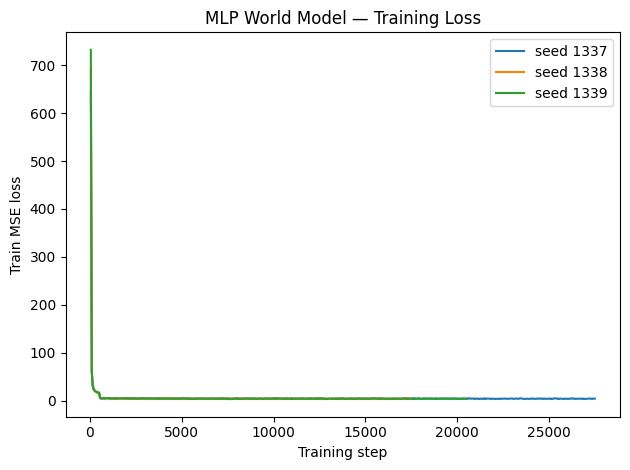

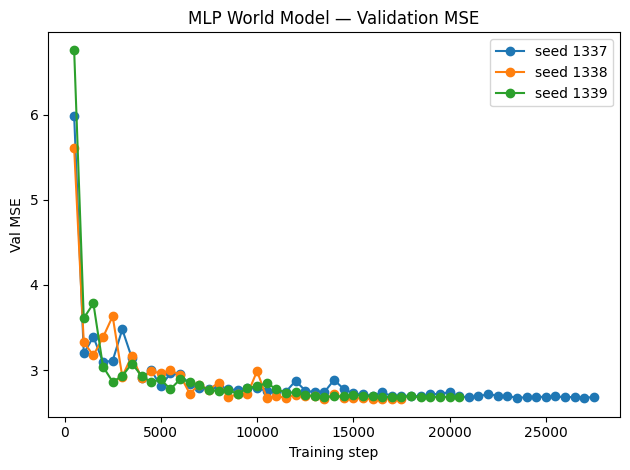

In [ ]:
# Cell 15: Plot learning curves (train loss + val MSE) for each seed
import matplotlib.pyplot as plt

plt.figure()
for lg in logs:
    plt.plot(lg["train_steps"], lg["train_loss"], label=f"seed {lg['seed']}")
plt.xlabel("Training step")
plt.ylabel("Train MSE loss")
plt.title("MLP World Model — Training Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
for lg in logs:
    plt.plot(lg["val_steps"], lg["val_mse"], marker="o", label=f"seed {lg['seed']}")
plt.xlabel("Training step")
plt.ylabel("Val MSE")
plt.title("MLP World Model — Validation MSE")
plt.legend()
plt.tight_layout()
plt.show()

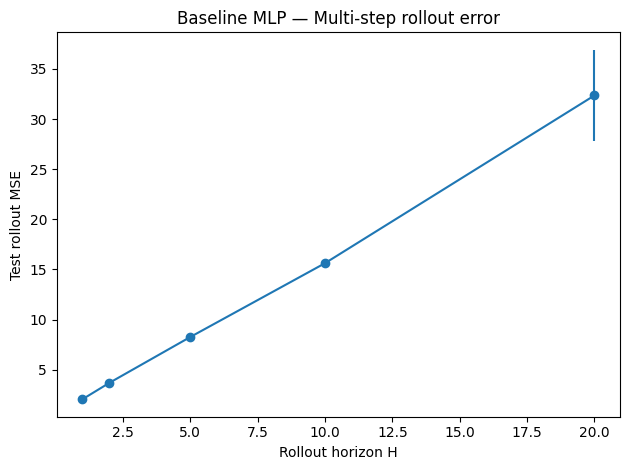

In [ ]:
# Cell 16: Plot rollout curves (mean ± std over seeds)
import matplotlib.pyplot as plt
import numpy as np

Hs = [1,2,5,10,20]
vals = np.array([[r["test_rollout_mse"][str(H)] for H in Hs] for r in all_rollouts], dtype=np.float64)

mean = vals.mean(axis=0)
std  = vals.std(axis=0, ddof=1) if vals.shape[0] > 1 else np.zeros_like(mean)

plt.figure()
plt.errorbar(Hs, mean, yerr=std, marker="o")
plt.xlabel("Rollout horizon H")
plt.ylabel("Test rollout MSE")
plt.title("Baseline MLP — Multi-step rollout error")
plt.tight_layout()
plt.show()

In [ ]:
# Final summary block — save complete baseline results

def mean_std(xs):
    xs = np.array(xs, dtype=np.float64)
    return float(xs.mean()), float(xs.std(ddof=1)) if len(xs) > 1 else 0.0

summary = {
    "model": "MLPWorldModel",
    "cfg": CFG,
    "seeds": seeds,
    "seq_meta": seq_meta,

    # one-step raw-space results
    "per_seed_raw": test_results,
    "raw_one_step_mse_mean": None,
    "raw_one_step_mse_std": None,

    # one-step normalized-space results
    "per_seed_normalized": test_results_norm,
    "normalized_one_step_mse_mean": None,
    "normalized_one_step_mse_std": None,

    # rollout raw-space results
    "per_seed_rollout_raw": all_rollouts,
    "rollout_raw_mse_mean": {},
    "rollout_raw_mse_std": {},

    # rollout normalized-space results
    "per_seed_rollout_normalized": all_rollouts_norm,
    "rollout_normalized_mse_mean": {},
    "rollout_normalized_mse_std": {},
}

# raw one-step
raw_vals = [r["test_mse"] for r in test_results]
summary["raw_one_step_mse_mean"], summary["raw_one_step_mse_std"] = mean_std(raw_vals)

# normalized one-step
norm_vals = [r["test_mse_normalized"] for r in test_results_norm]
summary["normalized_one_step_mse_mean"], summary["normalized_one_step_mse_std"] = mean_std(norm_vals)

# rollout stats
Hs = [1, 2, 5, 10, 20]

for H in Hs:
    raw_H = [r["test_rollout_mse"][str(H)] for r in all_rollouts]
    raw_m, raw_s = mean_std(raw_H)
    summary["rollout_raw_mse_mean"][str(H)] = raw_m
    summary["rollout_raw_mse_std"][str(H)] = raw_s

    norm_H = [r["test_rollout_mse_normalized"][str(H)] for r in all_rollouts_norm]
    norm_m, norm_s = mean_std(norm_H)
    summary["rollout_normalized_mse_mean"][str(H)] = norm_m
    summary["rollout_normalized_mse_std"][str(H)] = norm_s

summary_path = os.path.join(OUT_ROOT, "summary_full.json")
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Wrote:", summary_path)
print()
print("=== Final MLP Baseline Summary ===")
print("Raw one-step MSE mean/std:",
      summary["raw_one_step_mse_mean"],
      summary["raw_one_step_mse_std"])
print("Normalized one-step MSE mean/std:",
      summary["normalized_one_step_mse_mean"],
      summary["normalized_one_step_mse_std"])
print("Raw rollout MSE mean by horizon:",
      summary["rollout_raw_mse_mean"])
print("Normalized rollout MSE mean by horizon:",
      summary["rollout_normalized_mse_mean"])

Wrote: /content/drive/MyDrive/AIAGENT_FINAL/outputs/checkpoints/mlp_world_model/summary_full.json

=== Final MLP Baseline Summary ===
Raw one-step MSE mean/std: 2.060012843424479 0.0025283513522123416
Normalized one-step MSE mean/std: 15301.730813333334 2636.844676352191
Raw rollout MSE mean by horizon: {'1': 2.0600128512809674, '2': 3.6970094362167516, '5': 8.264792883295218, '10': 15.624129602739018, '20': 32.35195780553818}
Normalized rollout MSE mean by horizon: {'1': 15301.730023020835, '2': 14726.011813750001, '5': 14544.48165046875, '10': 16406.14803859375, '20': 23914.600400625}
